In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
SELECT timestamp
FROM checker
WHERE uid NOT LIKE 'admin_%' AND timestamp IS NOT NULL
"""
df = pd.io.sql.read_sql(query, conn)

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday

working_days = df[~df['weekday'].isin([5, 6])]['hour'].tolist()
weekends = df[df['weekday'].isin([5, 6])]['hour'].tolist()

In [17]:
len(working_days), len(weekends)

(2037, 1170)

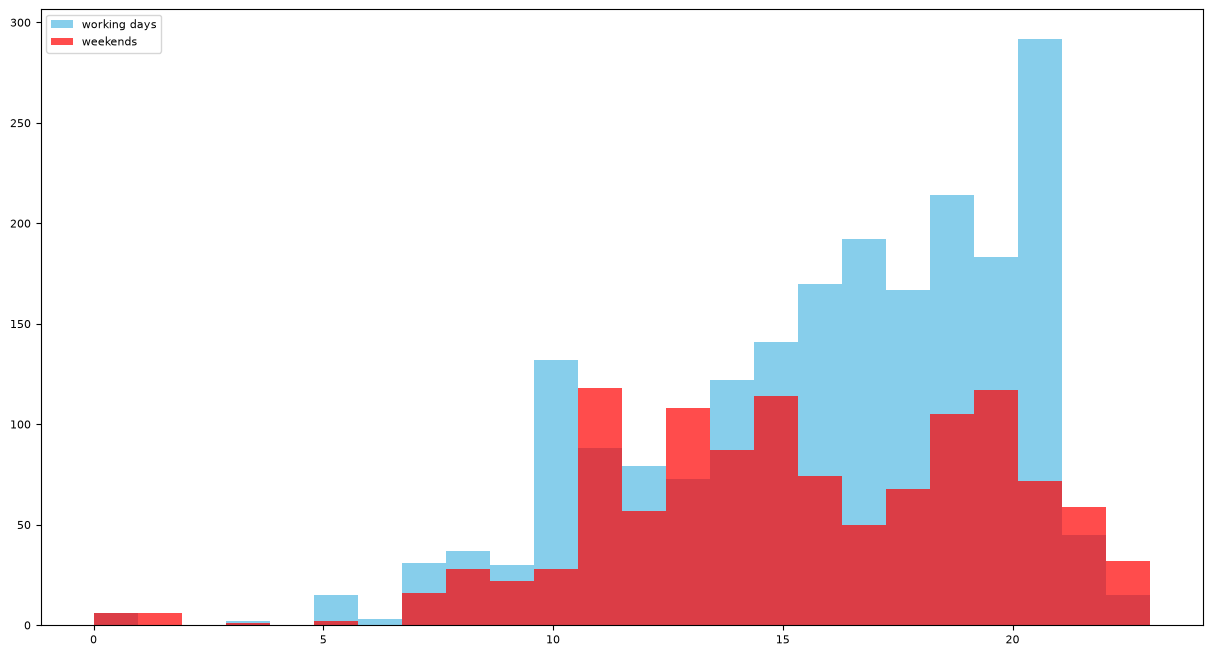

In [5]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.hist(working_days, bins=24, label='working days', color='skyblue')
ax.hist(weekends, bins=24, alpha=0.7, label='weekends', color='r')
ax.tick_params(axis='both', labelsize=8)
ax.legend(loc='upper left', fontsize=8)
plt.show()

In [6]:
conn.close()

Есть ли часы, когда общее число коммитов было выше в выходные, чем в рабочие дни?

Ответ: 11, 13, 22, 23